<a href="https://colab.research.google.com/github/ridhima011/TransformerBasedNLP-2210992151_2210992521-/blob/main/Untitled16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import all important** **libraries**

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Load dataset**

In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")

## **Show first rows**

In [ ]:
print(df.head())
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')


## **Convert labels to 0 and 1**

In [ ]:
df.columns = ['review', 'sentiment']
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

## **Split data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# **Convert text to numbers**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## **Train models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier()

lr.fit(X_train_vec, y_train)
rf.fit(X_train_vec, y_train)

RandomForestClassifier()

# **Predictions**

In [ ]:
lr_pred = lr.predict(X_test_vec)
rf_pred = rf.predict(X_test_vec)

# **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.87
Random Forest Accuracy: 0.8492


# **Accuracy graph**

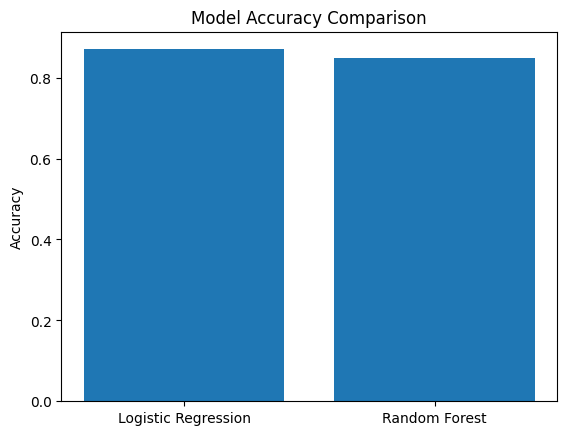

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
scores = [lr_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# **Confusion Matrix**

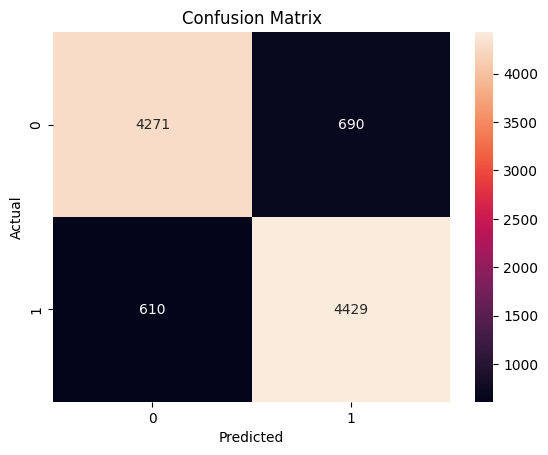

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()